HOUSE PRICE ANALYSIS

1. Introduction



This project focuses on analyzing a housing dataset to understand the key factors that influence house prices. The goal is to clean the data, explore relationships between different features, and extract meaningful insights using exploratory data analysis (EDA).

By examining variables such as property size, quality, and amenities, this analysis aims to identify the most significant drivers of housing prices and highlight patterns present in the dataset.

In [ ]:
import pandas as pd
df = pd.read_csv("data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


2. Data Cleaning

The dataset contained several missing values and inconsistencies that were addressed before analysis.

Columns with a high percentage of missing values such as PoolQC, MiscFeature, Alley, and Fence were removed as they provided limited analytical value.
Missing values were handled based on their meaning:
Categorical features where missing indicated absence (e.g., garage or basement-related features) were filled with "None".
Numerical features with moderate missing values were filled using the median to reduce the impact of outliers.
Certain numerical features where missing implied absence (e.g., masonry veneer area, garage year) were filled with 0.
Duplicate rows were checked and removed where necessary.
Outliers were identified in features such as living area (GrLivArea), where unusually large houses with low prices were present. These were removed to improve the reliability of the analysis.

After these steps, the dataset was cleaned and prepared for exploratory data analysis.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"], inplace=True, errors="ignore")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageFinish,81
GarageQual,81
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["GarageYrBlt"] = df["GarageYrBlt"].fillna("0")
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageQual"] = df["GarageQual"].fillna("None")

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
GarageCond,81
GarageType,81
BsmtFinType2,38
BsmtExposure,38
BsmtFinType1,37
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
df["GarageCond"] = df["GarageCond"].fillna("None")
df["GarageType"] = df["GarageType"].fillna("None")
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("None")
df["BsmtExposure"] = df["BsmtExposure"].fillna("None")
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("None")

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
BsmtCond,37
BsmtQual,37
MasVnrArea,8
Electrical,1
Id,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
df["BsmtCond"] = df["BsmtCond"].fillna("None")
df["BsmtQual"] = df["BsmtQual"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


3. Exploratory Data Analysis (EDA)

After cleaning the dataset, exploratory data analysis was performed to understand the distribution of house prices and the relationships between different features.

The target variable, SalePrice, was analyzed first. Its distribution was found to be right-skewed, indicating that most houses fall within a moderate price range, while a small number of properties have significantly higher prices.

Correlation analysis was used to identify features most strongly associated with SalePrice. Variables such as OverallQual, GrLivArea, GarageCars, and TotalBsmtSF showed strong positive relationships with price.

Visualizations were used to further explore these relationships. Scatter plots revealed a clear upward trend between living area and price, while boxplots showed that higher quality ratings correspond to higher median prices.

These observations helped identify the most influential features and guided further analysis.

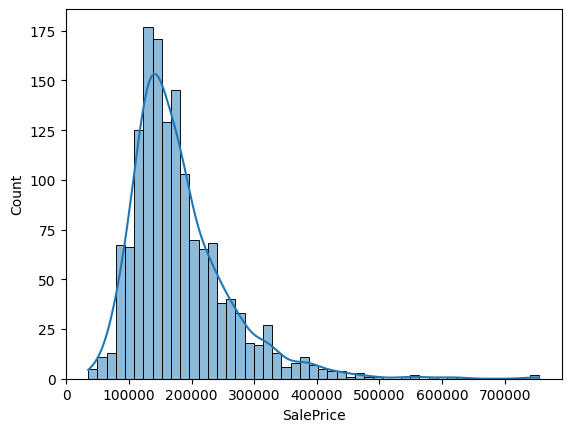

In [ ]:
df["SalePrice"].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


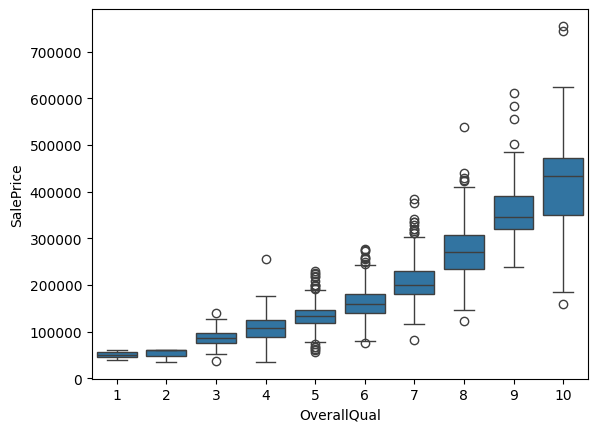

In [ ]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.show()

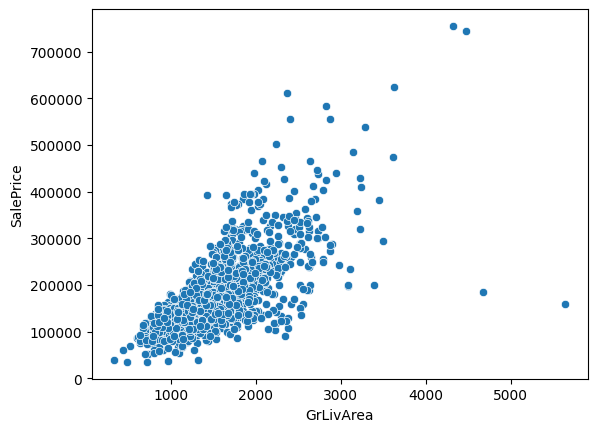

In [ ]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

In [ ]:
df[df["GrLivArea"] > 4000][["GrLivArea", "SalePrice"]]

,GrLivArea,SalePrice
523,4676,184750
691,4316,755000
1182,4476,745000
1298,5642,160000


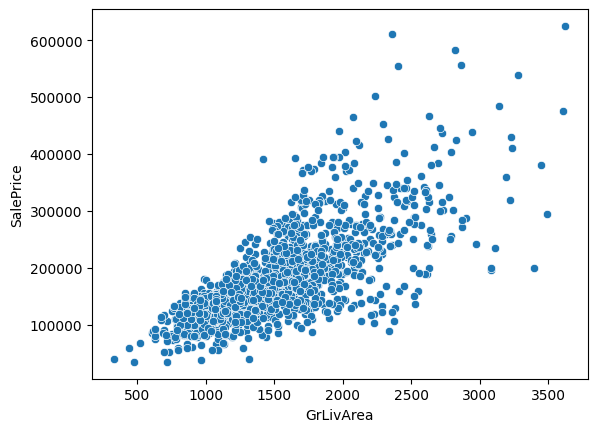

In [ ]:
df = df[df["GrLivArea"] < 4000]
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()

4. Feature Engineering

To improve the analysis, a new feature called TotalSF was created by combining the total basement area, first floor area, and second floor area.

This feature represents the overall usable space of a house more effectively than individual components. It was found to have a strong correlation with SalePrice, reinforcing the importance of total living space in determining property value.

In [ ]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).head(5)

,SalePrice
SalePrice,1.000000
TotalSF,0.825066
OverallQual,0.800858
GrLivArea,0.720516
GarageCars,0.649256


5. Key Insights



*   Overall quality of the house is the strongest factor influencing price, with higher quality homes commanding significantly higher values.

*   Living area has a strong positive relationship with price, indicating that larger homes tend to be more expensive.

*   Garage capacity and size contribute positively to house prices, suggesting that additional parking space adds value.

*   Basement and total square footage are important contributors, highlighting the role of overall space in property valuation.

*   House prices are right-skewed, with most properties in the mid-price range and a small number of high-value outliers.

*   A few unusually large houses were priced lower than expected; removing these outliers improved the clarity of relationships.

*   Newly constructed houses tend to have higher prices, indicating a preference for modern properties.

*   The engineered feature TotalSF showed a strong relationship with price, confirming that combined living space is a key determinant of value.


6. Conclusion

This analysis demonstrates that house prices are primarily driven by overall quality, total living space, and key amenities such as garages and bathrooms.

By cleaning the data, handling missing values appropriately, and removing outliers, more reliable patterns were identified. The insights gained from this analysis can be useful for understanding housing market trends and can serve as a foundation for building predictive models in future work.